In [1]:
import sys
sys.path.append("../")
import numpy as np
import matplotlib.pyplot as plt

from lowRank.NMLRSSE_NL_forwardEuler import NMLRSSE_NL_forwardEuler
from lowRank import compute_expectation as ce
from utils.noise_generator import ColoredNoiseGenerator_Cholesky
from utils import multi_index

# bath correlation function in Cai_2020_CPAM
Delta = 1
beta = 5/Delta
wc = 2.5 * Delta
wmax = 4 * wc
CapL = 200
factor = 1 - np.exp(-wmax/wc)
wl = -wc * np.log(1 - np.linspace(1, CapL, CapL)/CapL * factor)
cl = wl * np.sqrt((0.2 * wc/CapL) * factor)

_coth = 1.0 / np.tanh(0.5 * beta * wl)
_pref = (cl**2) / (2.0 * wl)
def bath_corr(t):
    t_arr = np.asarray(t)
    t1 = np.atleast_1d(t_arr).astype(float)
    phase = wl[:, None] * t1[None, :]             # shape: (CapL, len(t))
    out = np.sum(_pref[:, None] * (np.cos(phase) * _coth[:, None] - 1j * np.sin(phase)), axis=0)
    return out[0] if t_arr.ndim == 0 else out

# spin-boson model parameters
eps = [0, Delta, 2*Delta]
sx = np.array([[0, 1], [1, 0]], dtype=complex)
sz = np.array([[1, 0], [0, -1]], dtype=complex)
Hs = [Delta*sx + e*sz for e in eps]
L = sz

MultiIndex layers: 100%|██████████| 9/9 [00:00<00:00, 117.26it/s]


Low-rank decomposition done in 0.49 seconds.


MultiIndex layers: 100%|██████████| 9/9 [00:00<00:00, 116.81it/s]


Low-rank decomposition done in 0.54 seconds.


MultiIndex layers: 100%|██████████| 9/9 [00:00<00:00, 106.35it/s]


Low-rank decomposition done in 0.46 seconds.


Trajectories: 100%|██████████| 1000/1000 [03:21<00:00,  4.96it/s]


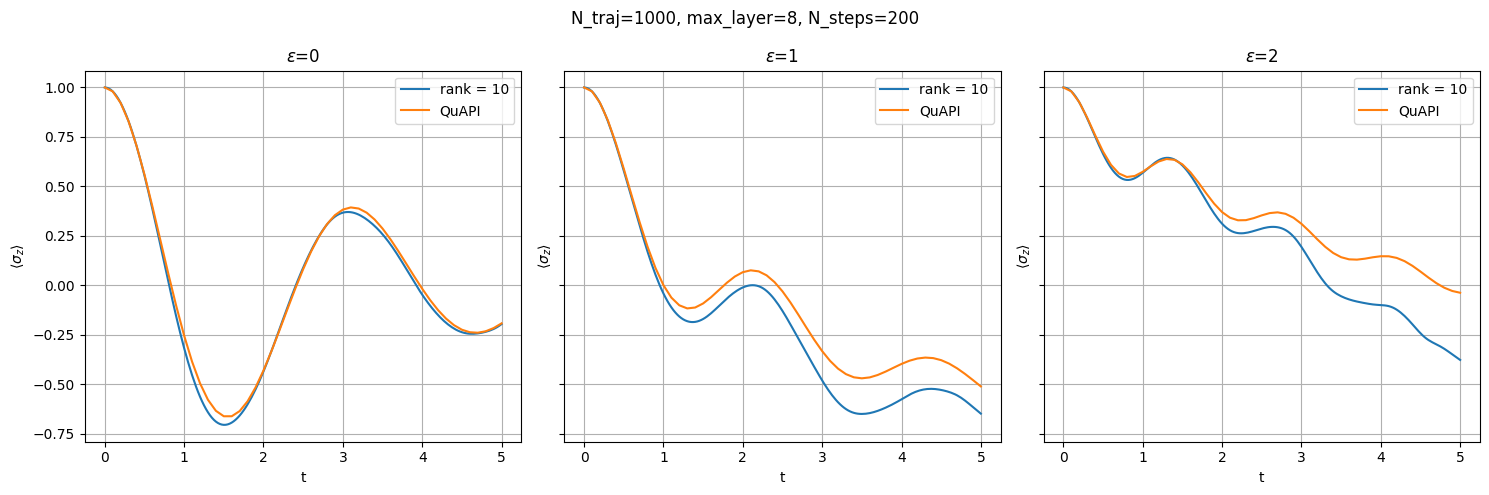

In [ ]:
# parameters for the simulation
tmax = 5.0 / Delta
N_steps = 200
psi0 = np.array([1.0, 0.0], dtype=complex)
N_traj = 1000
rank = 10
# hierarchy truncation (total order cutoff for the multi-index set)
# set smaller than N_steps to avoid combinatorial blow-up when rank grows
max_layer = 8
parallel_traj = True

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for idx in range(3):
    NMLRSSE_solver = NMLRSSE_NL_forwardEuler(
        Hs = Hs[idx],
        L = L,
        bath_corr = bath_corr,
        tmax = tmax,
        N_steps = N_steps,
        rank = rank,
        max_layer = max_layer,
    )
    psis = NMLRSSE_solver.solve(N_traj, psi0, parallel_traj=parallel_traj)
    sigma_z = ce.compute_expectation_value_nonlinear(psis, sz)
    axes[idx].plot(NMLRSSE_solver.t_grid, sigma_z, label='rank = {}'.format(rank))
    data = np.load("ref_spinboson/eps_{}.npz".format(eps[idx]))
    tgrid = data['t']
    sigmaz = data['sz']
    axes[idx].plot(tgrid, sigmaz, label='QuAPI')
    axes[idx].set_xlabel('t')
    axes[idx].set_ylabel(r'$\langle \sigma_z \rangle$')
    axes[idx].set_title(r'$\epsilon$={}'.format(eps[idx]))
    axes[idx].grid()
    axes[idx].legend()

plt.suptitle('N_traj={}, max_layer={}, N_steps={}'.format(N_traj, max_layer, N_steps))
plt.tight_layout()
plt.show()